#### SVM Classification in Python


In [1]:

#https://www.geeksforgeeks.org/machine-learning/classifying-data-using-support-vector-machinessvms-in-python/
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# Load the protein levels data -37 categories, median per sample, averaged acrossed samples 
import pandas as pd
ML_data = pd.read_csv("/Users/ruppb/Documents/Github/deepcell/20260331_Sig_medians_per_sample_forML.csv", sep=",")
ML_data.set_index('sample', inplace=True) 
ML_data

,DL_7_epi,DL_11_epi,DL_45_epi,DL_53_epi,DL_54_epi,CENTROID_Y_epi,AREA_epi,MIN_FERET_epi,SHORT_AXIS_epi,LBP_PERIPHERY_02_epi,...,DL_61_c1,Centroid_Y_c1,CIRCULARITY_c1,STANDARD_DEVIATION_c1,LBP_CENTER_02_c1,LBP_CENTER_03_c1,LBP_CENTER_07_c1,LBP_CENTER_10_c1,LBP_PERIPHERY_06_c1,LBP_PERIPHERY_07_c1
sample,,,,,,,,,,,,,,,,,,,,,
T1,0.079780,0.042150,-0.024440,0.022285,0.080189,24.332000,125.843500,10.409400,9.850325,0.044271,...,0.046171,24.016000,0.094981,0.087134,0.084921,0.064467,0.071292,0.299852,0.137168,0.091787
T2,0.081828,0.035267,-0.036310,0.027251,0.075629,24.253000,83.816630,9.401000,9.368859,0.042377,...,0.048028,23.700000,0.087549,0.088341,0.088763,0.058947,0.066570,0.307906,0.140611,0.092949
T3,0.086057,0.026766,-0.018050,0.029710,0.075825,24.174000,157.897300,11.441650,10.652220,0.042889,...,0.040200,24.806000,0.111476,0.091358,0.083780,0.063924,0.063033,0.301038,0.149476,0.090042
CRS1,0.067156,0.052456,0.001333,0.019337,0.095564,25.517000,233.088850,14.605435,14.101635,0.038562,...,0.006226,26.465000,0.063064,0.086052,0.092599,0.053334,0.057747,0.326543,0.133974,0.088092
CRS3,0.068846,0.064111,0.007888,0.019211,0.108144,26.649333,206.277533,12.853737,12.308030,0.039965,...,0.027697,28.703333,0.082845,0.075347,0.094078,0.052351,0.053949,0.321090,0.125539,0.076922
CRS4,0.075707,0.047559,-0.012405,0.014623,0.094568,26.109500,159.813300,10.585055,10.236989,0.039946,...,0.010122,25.675000,0.064752,0.079404,0.093902,0.056433,0.058723,0.322452,0.122736,0.084013
HC1,0.083860,0.030847,-0.014903,0.006809,0.076178,26.359667,162.765267,11.700937,11.267477,0.046130,...,0.035383,26.307000,0.094318,0.068339,0.087678,0.054454,0.067062,0.320775,0.134522,0.085780
HC2,0.062075,0.055954,-0.000182,0.019414,0.084634,25.201000,291.822950,15.641690,15.066525,0.044215,...,0.036929,25.793500,0.087501,0.068865,0.097046,0.057139,0.062941,0.321074,0.110881,0.081096
HC3,0.082354,0.034605,-0.012630,0.016414,0.089214,24.569000,174.248700,10.616730,9.908618,0.047769,...,0.039296,25.675000,0.087902,0.081728,0.089735,0.055894,0.057297,0.321777,0.138821,0.085496


In [3]:
X_train = ML_data[:11]
X_test = ML_data[11:]

print(X_train)
print(X_test)

        DL_7_epi  DL_11_epi  DL_45_epi  DL_53_epi  DL_54_epi  CENTROID_Y_epi  \
sample                                                                         
T1      0.079780   0.042150  -0.024440   0.022285   0.080189       24.332000   
T2      0.081828   0.035267  -0.036310   0.027251   0.075629       24.253000   
T3      0.086057   0.026766  -0.018050   0.029710   0.075825       24.174000   
CRS1    0.067156   0.052456   0.001333   0.019337   0.095564       25.517000   
CRS3    0.068846   0.064111   0.007888   0.019211   0.108144       26.649333   
CRS4    0.075707   0.047559  -0.012405   0.014623   0.094568       26.109500   
HC1     0.083860   0.030847  -0.014903   0.006809   0.076178       26.359667   
HC2     0.062075   0.055954  -0.000182   0.019414   0.084634       25.201000   
HC3     0.082354   0.034605  -0.012630   0.016414   0.089214       24.569000   
HC4     0.062739   0.057003   0.001314   0.022758   0.098486       24.174000   
HC5     0.065887   0.078620   0.020633  

In [4]:
y_train=[1,1,1,0,0,0,0,0,0,0,0]
y_test = [0,0]


print(y_train)
print(y_test)

[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0]


In [5]:
# 3. Scale the features (highly recommended for SVMs)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled
X_test_scaled

array([[-0.58164044,  1.15456586,  0.38725139,  0.36480257,  0.56143373,
         1.18312452,  0.06294317,  0.28142383,  0.36682539, -1.48669844,
         0.03086032,  0.51234059, -2.21709042,  0.22189402, -1.29783674,
        -0.13640671, -1.71434428, -0.718576  , -0.2025192 , -0.2385708 ,
        -0.06744162, -0.65719929, -1.61328489,  0.06103158,  0.32795289,
        -1.25803447, -1.20064848,  1.28814815,  1.32118557,  0.26596059,
         0.6568847 , -0.17930654,  0.39051598, -0.25801422, -0.19532966,
        -0.71482063,  0.85900549],
       [-0.78901232,  0.87514643,  0.88611619, -0.60071144,  1.08171779,
         0.19922028,  0.72844127,  1.14805847,  1.20046217,  0.08875437,
         0.70555746,  0.33483286, -0.01149141,  0.86017531, -1.03320884,
        -0.11245979, -1.89857698, -1.89272494,  1.51710713, -0.39201035,
        -0.05198241, -0.17749994, -1.24889984, -0.06476876,  0.19728759,
        -0.79918353,  0.52545745,  0.88002795,  0.07124482, -0.31342414,
        -0.43798

In [6]:
svm_classifier = SVC(kernel='linear', C=1.0, random_state=42)
svm_classifier.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [7]:
y_pred = svm_classifier.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")


Accuracy: 1.00


#### Logistic regression

In [8]:
#https://www.geeksforgeeks.org/machine-learning/ml-logistic-regression-using-python/
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score

In [9]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [10]:
y_pred = model.predict(X_test)
y_pred

C:\Users\ruppb\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


array([0, 0])

In [11]:
accuracy = accuracy_score(y_test, y_pred)
print(f"accuracy: {round(accuracy,2)}")

accuracy: 1.0


C:\Users\ruppb\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\ruppb\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\ruppb\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


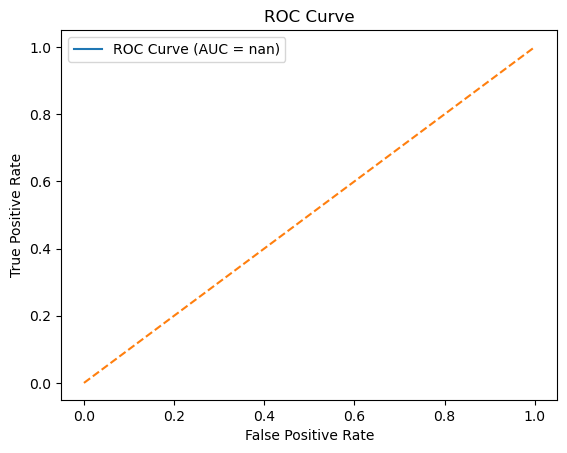

In [12]:
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--") 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#### Logisitic regression with LOOCV

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score
import numpy as np

In [3]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)
loo = LeaveOneOut()

y_true = []
y_pred = []

In [4]:
import pandas as pd

# Example DataFrame
ML_data_2 = pd.read_csv("/Users/ruppb/Documents/Github/deepcell/20260331_Sig_medians_per_sample_forML_target_limited.csv", sep=",")
ML_data_2= ML_data_2.reset_index(drop=True)
ML_data_2

,target,DL_7_epi,DL_11_epi,DL_45_epi,DL_53_epi,DL_54_epi,CENTROID_Y_epi,AREA_epi,MIN_FERET_epi,SHORT_AXIS_epi,...,DL_61_c1,Centroid_Y_c1,CIRCULARITY_c1,STANDARD_DEVIATION_c1,LBP_CENTER_02_c1,LBP_CENTER_03_c1,LBP_CENTER_07_c1,LBP_CENTER_10_c1,LBP_PERIPHERY_06_c1,LBP_PERIPHERY_07_c1
0,1,0.079780,0.042150,-0.024440,0.022285,0.080189,24.332000,125.843500,10.409400,9.850325,...,0.046171,24.016000,0.094981,0.087134,0.084921,0.064467,0.071292,0.299852,0.137168,0.091787
1,1,0.081828,0.035267,-0.036310,0.027251,0.075629,24.253000,83.816630,9.401000,9.368859,...,0.048028,23.700000,0.087549,0.088341,0.088763,0.058947,0.066570,0.307906,0.140611,0.092949
2,1,0.086057,0.026766,-0.018050,0.029710,0.075825,24.174000,157.897300,11.441650,10.652220,...,0.040200,24.806000,0.111476,0.091358,0.083780,0.063924,0.063033,0.301038,0.149476,0.090042
3,0,0.067156,0.052456,0.001333,0.019337,0.095564,25.517000,233.088850,14.605435,14.101635,...,0.006226,26.465000,0.063064,0.086052,0.092599,0.053334,0.057747,0.326543,0.133974,0.088092
4,0,0.068846,0.064111,0.007888,0.019211,0.108144,26.649333,206.277533,12.853737,12.308030,...,0.027697,28.703333,0.082845,0.075347,0.094078,0.052351,0.053949,0.321090,0.125539,0.076922
5,0,0.075707,0.047559,-0.012405,0.014623,0.094568,26.109500,159.813300,10.585055,10.236989,...,0.010122,25.675000,0.064752,0.079404,0.093902,0.056433,0.058723,0.322452,0.122736,0.084013
6,0,0.083860,0.030847,-0.014903,0.006809,0.076178,26.359667,162.765267,11.700937,11.267477,...,0.035383,26.307000,0.094318,0.068339,0.087678,0.054454,0.067062,0.320775,0.134522,0.085780
7,0,0.062075,0.055954,-0.000182,0.019414,0.084634,25.201000,291.822950,15.641690,15.066525,...,0.036929,25.793500,0.087501,0.068865,0.097046,0.057139,0.062941,0.321074,0.110881,0.081096
8,0,0.082354,0.034605,-0.012630,0.016414,0.089214,24.569000,174.248700,10.616730,9.908618,...,0.039296,25.675000,0.087902,0.081728,0.089735,0.055894,0.057297,0.321777,0.138821,0.085496
9,0,0.062739,0.057003,0.001314,0.022758,0.098486,24.174000,220.045150,13.726855,13.143455,...,0.013609,24.332000,0.071008,0.075769,0.094274,0.050902,0.052144,0.340236,0.115221,0.075195


In [5]:

X = ML_data_2[[
    'DL_7_epi', 'DL_11_epi', 'DL_45_epi', 'DL_53_epi', 'DL_54_epi',
    'CENTROID_Y_epi', 'AREA_epi', 'MIN_FERET_epi', 'SHORT_AXIS_epi',
    'LBP_PERIPHERY_02_epi',
    'DL_0_C1', 'DL_7_C1', 'DL_12_C1', 'DL_14_C1', 'DL_21_c1',
    'DL_23_c1', 'DL_24_c1', 'DL_25_c1', 'DL_26_c1', 'DL_27_c1',
    'DL_28_c1', 'DL_29_c1', 'DL_31_c1', 'DL_33_c1', 'DL_37_c1',
    'DL_39_c1', 'DL_56_c1', 'DL_61_c1',
    'Centroid_Y_c1', 'CIRCULARITY_c1', 'STANDARD_DEVIATION_c1',
    'LBP_CENTER_02_c1', 'LBP_CENTER_03_c1', 'LBP_CENTER_07_c1',
    'LBP_CENTER_10_c1', 'LBP_PERIPHERY_06_c1', 'LBP_PERIPHERY_07_c1'
]].values

y = ML_data_2['target'].values

In [6]:
for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    y_true.append(y_test[0])
    y_pred.append(pred[0])

In [7]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88         8
           1       0.67      0.67      0.67         3

    accuracy                           0.82        11
   macro avg       0.77      0.77      0.77        11
weighted avg       0.82      0.82      0.82        11



In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1:", f1_score(y_true, y_pred))

Precision: 0.6666666666666666
Recall: 0.6666666666666666
F1: 0.6666666666666666


In [9]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[7 1]
 [1 2]]


#### Retry with only 4 epi features 


In [10]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)
loo = LeaveOneOut()

y_true = []
y_pred = []

In [11]:

X = ML_data_2[[
    'DL_7_epi', 'DL_45_epi', 'DL_54_epi',
    'AREA_epi'
]].values

y = ML_data_2['target'].values

In [12]:
X = ML_data_2[[
    'DL_37_c1', 'DL_45_epi', 'DL_54_epi',
    'LBP_CENTER_10_c1'
]].values

y = ML_data_2['target'].values

In [13]:
for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    y_true.append(y_test[0])
    y_pred.append(pred[0])

In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.88      0.93         8
           1       0.75      1.00      0.86         3

    accuracy                           0.91        11
   macro avg       0.88      0.94      0.90        11
weighted avg       0.93      0.91      0.91        11



In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1:", f1_score(y_true, y_pred))

Precision: 0.75
Recall: 1.0
F1: 0.8571428571428571


In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[7 1]
 [0 3]]


#### Annotate data frame

In [17]:
import pandas as pd

# Example DataFrame
ML_data_2 = pd.read_csv("/Users/ruppb/Documents/Github/deepcell/20260331_Sig_medians_per_sample_forML_target_limited.csv", sep=",")
ML_data_2

,target,DL_7_epi,DL_11_epi,DL_45_epi,DL_53_epi,DL_54_epi,CENTROID_Y_epi,AREA_epi,MIN_FERET_epi,SHORT_AXIS_epi,...,DL_61_c1,Centroid_Y_c1,CIRCULARITY_c1,STANDARD_DEVIATION_c1,LBP_CENTER_02_c1,LBP_CENTER_03_c1,LBP_CENTER_07_c1,LBP_CENTER_10_c1,LBP_PERIPHERY_06_c1,LBP_PERIPHERY_07_c1
0,1,0.079780,0.042150,-0.024440,0.022285,0.080189,24.332000,125.843500,10.409400,9.850325,...,0.046171,24.016000,0.094981,0.087134,0.084921,0.064467,0.071292,0.299852,0.137168,0.091787
1,1,0.081828,0.035267,-0.036310,0.027251,0.075629,24.253000,83.816630,9.401000,9.368859,...,0.048028,23.700000,0.087549,0.088341,0.088763,0.058947,0.066570,0.307906,0.140611,0.092949
2,1,0.086057,0.026766,-0.018050,0.029710,0.075825,24.174000,157.897300,11.441650,10.652220,...,0.040200,24.806000,0.111476,0.091358,0.083780,0.063924,0.063033,0.301038,0.149476,0.090042
3,0,0.067156,0.052456,0.001333,0.019337,0.095564,25.517000,233.088850,14.605435,14.101635,...,0.006226,26.465000,0.063064,0.086052,0.092599,0.053334,0.057747,0.326543,0.133974,0.088092
4,0,0.068846,0.064111,0.007888,0.019211,0.108144,26.649333,206.277533,12.853737,12.308030,...,0.027697,28.703333,0.082845,0.075347,0.094078,0.052351,0.053949,0.321090,0.125539,0.076922
5,0,0.075707,0.047559,-0.012405,0.014623,0.094568,26.109500,159.813300,10.585055,10.236989,...,0.010122,25.675000,0.064752,0.079404,0.093902,0.056433,0.058723,0.322452,0.122736,0.084013
6,0,0.083860,0.030847,-0.014903,0.006809,0.076178,26.359667,162.765267,11.700937,11.267477,...,0.035383,26.307000,0.094318,0.068339,0.087678,0.054454,0.067062,0.320775,0.134522,0.085780
7,0,0.062075,0.055954,-0.000182,0.019414,0.084634,25.201000,291.822950,15.641690,15.066525,...,0.036929,25.793500,0.087501,0.068865,0.097046,0.057139,0.062941,0.321074,0.110881,0.081096
8,0,0.082354,0.034605,-0.012630,0.016414,0.089214,24.569000,174.248700,10.616730,9.908618,...,0.039296,25.675000,0.087902,0.081728,0.089735,0.055894,0.057297,0.321777,0.138821,0.085496
9,0,0.062739,0.057003,0.001314,0.022758,0.098486,24.174000,220.045150,13.726855,13.143455,...,0.013609,24.332000,0.071008,0.075769,0.094274,0.050902,0.052144,0.340236,0.115221,0.075195


In [18]:
ML_data_2= ML_data_2.reset_index(drop=True)

In [19]:
X = ML_data_2[[
    'DL_7_epi', 'DL_11_epi', 'DL_45_epi', 'DL_53_epi', 'DL_54_epi',
    'CENTROID_Y_epi', 'AREA_epi', 'MIN_FERET_epi', 'SHORT_AXIS_epi',
    'LBP_PERIPHERY_02_epi',
    'DL_0_C1', 'DL_7_C1', 'DL_12_C1', 'DL_14_C1', 'DL_21_c1',
    'DL_23_c1', 'DL_24_c1', 'DL_25_c1', 'DL_26_c1', 'DL_27_c1',
    'DL_28_c1', 'DL_29_c1', 'DL_31_c1', 'DL_33_c1', 'DL_37_c1',
    'DL_39_c1', 'DL_56_c1', 'DL_61_c1',
    'Centroid_Y_c1', 'CIRCULARITY_c1', 'STANDARD_DEVIATION_c1',
    'LBP_CENTER_02_c1', 'LBP_CENTER_03_c1', 'LBP_CENTER_07_c1',
    'LBP_CENTER_10_c1', 'LBP_PERIPHERY_06_c1', 'LBP_PERIPHERY_07_c1'
]].values

y = ML_data_2['target'].values

In [20]:
X = ML_data_2[[
    'DL_7_epi', 'DL_45_epi', 'DL_54_epi',
    'AREA_epi'
]].values

y = ML_data_2['target'].values

In [32]:
X = ML_data_2[[
    'DL_37_c1', 'DL_45_epi', 'DL_54_epi',
    'LBP_CENTER_10_c1'
]].values

y = ML_data_2['target'].values

In [33]:
X = ML_data_2[[
    'DL_45_epi'
]].values

y = ML_data_2['target'].values

In [34]:
#https://scikit-learn.org/stable/modules/cross_validation.html

from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LogisticRegression

loo = LeaveOneOut()
model = LogisticRegression(class_weight='balanced', max_iter=1000)

results = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    pred = model.predict(X_test)[0]
    prob = model.predict_proba(X_test)[0][1]

    results.append({
        'predicted': pred,
        'probability': prob,
        'actual': y_test[0]
    })

In [35]:
import pandas as pd

results_df = pd.DataFrame(results)

In [36]:
results_df.shape 

(11, 3)

In [37]:
final_df = ML_data_2.copy()

# Assign row-by-row using .iloc
final_df['predicted'] = results_df['predicted'].iloc[:].values
final_df['probability'] = results_df['probability'].iloc[:].values
final_df['actual'] = results_df['actual'].iloc[:].values 

In [38]:
print(final_df)

    target  DL_7_epi  DL_11_epi  DL_45_epi  DL_53_epi  DL_54_epi  \
0        1  0.079780   0.042150  -0.024440   0.022285   0.080189   
1        1  0.081828   0.035267  -0.036310   0.027251   0.075629   
2        1  0.086057   0.026766  -0.018050   0.029710   0.075825   
3        0  0.067156   0.052456   0.001333   0.019337   0.095564   
4        0  0.068846   0.064111   0.007888   0.019211   0.108144   
5        0  0.075707   0.047559  -0.012405   0.014623   0.094568   
6        0  0.083860   0.030847  -0.014903   0.006809   0.076178   
7        0  0.062075   0.055954  -0.000182   0.019414   0.084634   
8        0  0.082354   0.034605  -0.012630   0.016414   0.089214   
9        0  0.062739   0.057003   0.001314   0.022758   0.098486   
10       0  0.065887   0.078620   0.020633   0.023495   0.109918   

    CENTROID_Y_epi    AREA_epi  MIN_FERET_epi  SHORT_AXIS_epi  ...  \
0        24.332000  125.843500      10.409400        9.850325  ...   
1        24.253000   83.816630       9.4010

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.88      0.93         8
           1       0.75      1.00      0.86         3

    accuracy                           0.91        11
   macro avg       0.88      0.94      0.90        11
weighted avg       0.93      0.91      0.91        11



In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[7 1]
 [0 3]]


In [41]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [42]:
y_true = final_df['actual'].values
y_prob = final_df['predicted'].values

In [58]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
y_prob

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

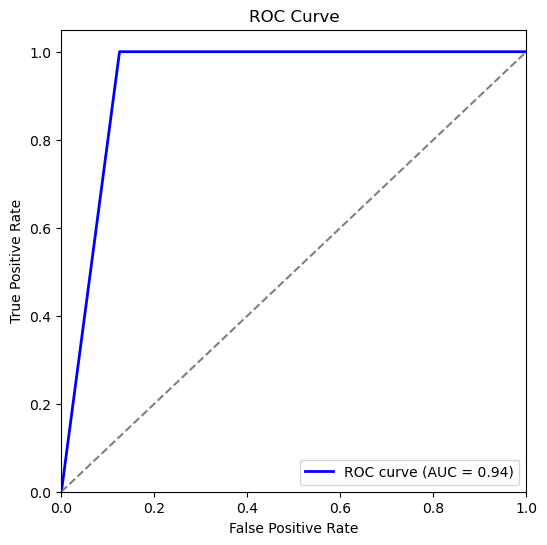

AttributeError: 'Figure' object has no attribute 'savefig'

In [59]:
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # diagonal = random
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

fig.savefig("roc_curve.svg", bbox_inches='tight')  # <-- more reliable
plt.show()


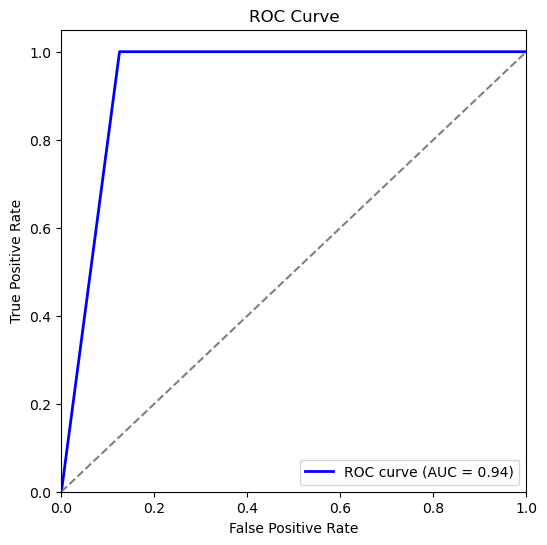

In [60]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,6))

ax.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc="lower right")

plt.savefig("roc_curve.svg", bbox_inches='tight')  # fallback method
plt.show()

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from numpy import mean
from numpy import absolute
from numpy import sqrt
import pandas as pd

In [51]:
cv = LeaveOneOut()

#build multiple linear regression model
model = LinearRegression()

#use LOOCV to evaluate model
scores = cross_val_score(model, X, y, scoring='neg_mean_absolute_error',
                         cv=cv, n_jobs=-1)

#view mean absolute error
mean(absolute(scores))

0.5974760277738312

In [47]:
# Step 4: View the individual scores and the mean accuracy
print(f"Individual fold accuracies: {scores}")
print(f"Mean accuracy: {scores.mean()*100:.2f}%")

Individual fold accuracies: [1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1.]
Mean accuracy: 81.82%
